### ১. বায়াস (Bias) কী?
মেশিন লার্নিং-এর ভাষায়, Bias হলো একটি মডেলের সরলতা বা একগুঁয়েমি। যখন কোনো মডেলকে বাস্তব জগতের কোনো জটিল ডাটার ওপর ট্রেইন করা হয়, কিন্তু মডেলটি নিজে এতটাই সাধারণ (Simple) যে সে ডাটার ভেতরের জটিল প্যাটার্ন বা রিলেশনশিপ বুঝতে পারে না, তখন তাকে High Bias বা উচ্চ বায়াস বলা হয়।

ভিডিওর উদাহরণ অনুযায়ী, ডাটা যদি একটি কার্ভ (Curve) বা বাঁকা লাইনের মতো হয়, আর আমরা যদি সেখানে একটি সাধারণ Linear Regression মডেল ব্যবহার করি, তবে মডেলটি জোর করে ডাটার মাঝখান দিয়ে একটি সোজা লাইন টানবে। এর ফলে মডেলের প্রেডিকশন ভুল হতে শুরু করবে।

### ২. আন্ডারফিটিং (Underfitting)
হাই-বায়াস (High Bias) এর সরাসরি ফলাফল হলো Underfitting। আন্ডারফিটিং মানে হলো মডেলটি আপনার ডাটা থেকে কিছুই শিখতে পারেনি।

ভুল ধারণা (Myth): অনেক বিগিনার মনে করেন যে মডেল ভালো পারফর্ম না করলে আরও বেশি ডাটা যোগ করলেই হয়তো ঠিক হয়ে যাবে। ভিডিওতে স্পষ্টভাবে বলা হয়েছে যে, মডেল যদি আন্ডারফিটেড হয়, তবে কোটি কোটি ডাটা দিলেও এর পারফরম্যান্স উন্নত হবে না, কারণ মডেলের নিজস্ব ক্ষমতাই নেই ওই প্যাটার্ন ধরার।

### ৩. বায়াস (Bias) কীভাবে চেক করতে হয়?
সাধারণত আমরা মডেলের নির্ভুলতা বা পারফরম্যান্স পরীক্ষা করি Test Set বা পরীক্ষার ডাটা দিয়ে। কিন্তু Bias বা Underfitting চেক করতে হয় <b>Training Set</b> দিয়ে। অর্থাৎ, যে ডাটা দিয়ে মডেলকে শেখানো হয়েছে, সেই ডাটা দিয়েই আবার প্রেডিকশন করিয়ে দেখতে হয় যে মডেলটি ডাটার মূল প্যাটার্নটি ধরতে পেরেছে কি না।

### ৪. সমাধান (How to fix High Bias?)
বায়াস বা আন্ডারফিটিং দূর করার মূল উপায় হলো Model Complexity (মডেলের জটিলতা) বাড়ানো। ভিডিওতে দেখানো হয়েছে কীভাবে একটি সাধারণ লিনিয়ার রিগ্রেশন মডেলে Polynomial Features যোগ করে সেটির ক্ষমতা বাড়িয়ে একটি নন-লিনিয়ার কার্ভড ডাটার প্যাটার্ন নিখুঁতভাবে ধরা যায়।

## ধাপ ১: সিন্থেটিক নন-লিনিয়ার ডাটা তৈরি ও ভিজ্যুয়ালাইজেশন

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

np.random.seed(0)
X = np.linspace(-3, 3, 100)
y= X**2+ np.random.normal(0, 0.5, size=(100))

import pandas as pd
df= pd.DataFrame({"x": X, "y": y})
df.head()

,x,y
0,-3.000000,9.882026
1,-2.939394,8.840115
2,-2.878788,8.776789
3,-2.818182,9.062595
4,-2.757576,8.538003


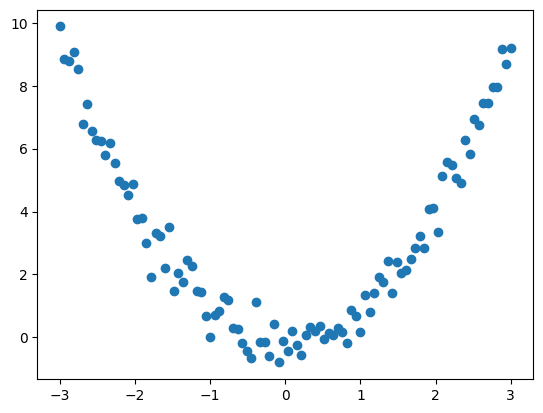

In [8]:
plt.scatter(df['x'], df['y'])

In [13]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()

X, y = df[['x']], df['y']

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
pred= model.predict(X)

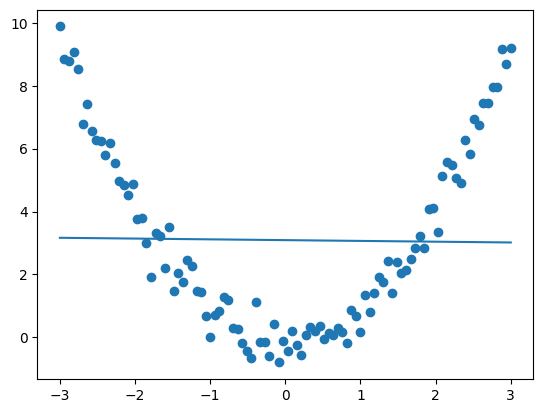

In [16]:
plt.scatter(X, y)
plt.plot(X, pred)
plt.show()

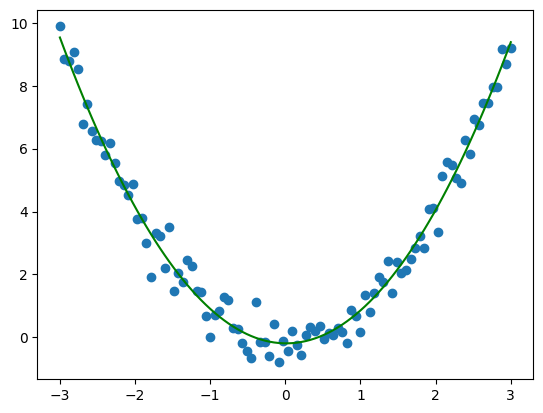

In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
poly_model= Pipeline([
    ("poly", PolynomialFeatures (degree=2)),
    ("lr", LinearRegression())
])
poly_model.fit(X, y)
y_poly_pred= poly_model.predict(X)
plt.scatter(X, y)
plt.plot(X, y_poly_pred, color="green")
plt.show()